Import Libraries

In [1]:
import pandas as pd
import re
import ast
import numpy as np
import matplotlib.pyplot as plt
from haversine import haversine
import os
import math
import geopandas as gpd
import contextily as ctx
import random
import seaborn as sns
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
import opendssdirect as dss

Load data


In [2]:
EVplanningFolder = "Results4"
def get_current_path():
    """
    Get the current working directory.
    """
    os.chdir(r"C:\Users\jingb\Box\EVPlanning_iScience\GridIntegration")
    cur_path = os.getcwd()
    return cur_path

In [14]:
# derive EVplanData to nearest bus then to power region
def derive_nearest_bus(caseidx):
    # get bus coordinates path
    Buscoords_path = "allbuscoords.csv" # Bus coordinates data
    BusData = pd.read_csv(Buscoords_path, index_col=None)
    
    EV_optm_exi_path = f"{EVplanningFolder}\\Expanded_existing_chargers_set{caseidx}.xlsx" # planned EV existing in meters
    EV_optm_new_path = f"{EVplanningFolder}\\newly_opened_chargers_set{caseidx}.xlsx" # planned EV new in meters
    EVplanData1 = pd.read_excel(EV_optm_exi_path, index_col=None) if os.path.exists(EV_optm_exi_path) else pd.DataFrame() # Create an empty DataFrame if the file does not exist
    EVplanData1.rename(columns={'pri_idx_df_EV_existing': 'charger', 'capacity': 'Extra ports added', 'X': 'x_coord', 'Y': 'y_coord'}, inplace=True)
    EVplanData2 = pd.read_excel(EV_optm_new_path, index_col=None) if os.path.exists(EV_optm_new_path) else pd.DataFrame() # Create an empty DataFrame if the file does not exist
    EVplanData2.rename(columns={'pri_idx_df_EV_predict': 'charger', 'capacity': 'Extra ports added', 'X': 'x_coord', 'Y': 'y_coord'}, inplace=True)
    # concatenate the two dataframes EVplanData1 and EVplanData2
    EVplanData = pd.concat([EVplanData1, EVplanData2], ignore_index=True)
    # convert meters to lat/lon
    gdf_ev = gpd.GeoDataFrame(EVplanData, geometry=gpd.points_from_xy(EVplanData.x_coord, EVplanData.y_coord), crs="EPSG:3857")
    gdf_ev = gdf_ev.to_crs(epsg=4326)
    EVplanData['Latitude'] = gdf_ev.geometry.y
    EVplanData['Longitude'] = gdf_ev.geometry.x
    EVplanData = nearest_bus(EVplanData, BusData)
    return EVplanData, BusData


def nearest_bus(df, BusData):
    ev_coords = np.radians(df[['Latitude','Longitude']].to_numpy())
    bus_coords = np.radians(BusData[['Latitude','Longitude']].to_numpy())
    tree = cKDTree(bus_coords)
    distances, idxes = tree.query(ev_coords, k=1)
    df['NearestBus'] = BusData['Location'].iloc[idxes].values
    return df


AusGridPath = r"D:\AUS"
masterpath = r"scenarios\base_timeseries\opendss_no_loadshapes\Master.dss"
buscoords_path = r"scenarios\base_timeseries\opendss_no_loadshapes\Buscoords.dss"
def compile_dss_files(AusGridPath, masterpath, buscoords_path):
    subGridPath = os.listdir(AusGridPath)
    MasterPaths = [
        os.path.join(AusGridPath, a, masterpath)
        for a in subGridPath
    ]
    BusPaths = [
        os.path.join(AusGridPath, a, buscoords_path)
        for a in subGridPath
    ]
    return MasterPaths, BusPaths, subGridPath



def plot_map_Vmin(caseidx, cur_path,plot_flag=False):
    # Load data
    EVplanData, BusData = derive_nearest_bus(caseidx)
    results_directory = os.path.join(cur_path,  f"Cases{EVplanningFolder}\\Case{caseidx}HostingCapacity")

    # List all CSV files in the directory
    csv_files = [f for f in os.listdir(results_directory) if f.endswith('.csv')]
    results_row = [csv_file.split("_")[1] for csv_file in csv_files]
    results_HC = {}
    for i, csv_file in enumerate(csv_files):
        # Read the CSV file
        df_hostcap = pd.read_csv(os.path.join(results_directory, csv_file))
        df_hostcap = df_hostcap.sort_values('Vmin', ascending=False).reset_index(drop=True)
        Vmin0 = df_hostcap['Vmin'].iloc[1]
        threshold = Vmin0*0.95
        # Find the first index where Vmin < threshold
        idx = df_hostcap[df_hostcap['Vmin'] < threshold].index.min()
        pwr_sys_nam = csv_file.split("_")[1]
        if pwr_sys_nam not in results_HC:
            results_HC[pwr_sys_nam] = []
        if pd.notna(idx):
            Host_Capacity = df_hostcap.loc[idx:, 'Capacity'].min()
            # print(f"{pwr_sys_nam}: {Host_Capacity}kW")
            results_HC[pwr_sys_nam].append(Host_Capacity)
        else:
            if df_hostcap['Capacity'].max() <1:
                # print(f"{pwr_sys_nam}: No Vmin value is below the threshold.")      
                results_HC[pwr_sys_nam].append(np.nan)
            else:
                results_HC[pwr_sys_nam].append(df_hostcap['Capacity'].max())
                # print(f"{pwr_sys_nam}: No Vmin value is below the threshold, using max capacity {df_hostcap['Capacity'].max()}kW")


    if plot_flag:
        # Plotting
        fig,axs = plt.subplots(2,1,figsize=(10, 10))  
        # Plotting bus network
        axs[0].scatter(BusData['Longitude'], BusData['Latitude'], c='blue', label='Bus Network', s=10)
        # Plotting EV charger coordinates
        axs[0].scatter(EVplanData['Longitude'], EVplanData['Latitude'], c='green', label='EV Chargers', marker='x')
        # Labels and legend
        axs[0].set_xlabel('Longitude')
        axs[0].set_ylabel('Latitude')
        axs[0].set_title('EV Charger and Bus Locations')
        axs[0].legend()
        axs[0].grid(True)
    
        for i, csv_file in enumerate(csv_files):
        # Read the CSV file
            df_hostcap = pd.read_csv(os.path.join(results_directory, csv_file))
            df_hostcap = df_hostcap.sort_values('Vmin', ascending=False).reset_index(drop=True)
            Vmin0 = df_hostcap['Vmin'].iloc[1]
            threshold = Vmin0*0.95
            # Find the first index where Vmin < threshold
            idx = df_hostcap[df_hostcap['Vmin'] < threshold].index.min()
            pwr_sys_nam = csv_file.split("_")[1]
            if pd.notna(idx):
                Host_Capacity = df_hostcap.loc[idx:, 'Capacity'].min()
                print(f"{pwr_sys_nam}: {Host_Capacity}kW")
            else:
                print(f"{pwr_sys_nam}: No Vmin value is below the threshold.")       
            # Plot the data
            axs[1].scatter(df_hostcap['Capacity'], df_hostcap['Vmin'], alpha=0.6, label=csv_file.split("_")[1])
            # set the title to the second part of after "_"
            # axes[1].set_title(csv_file.split("_")[1]+' Capacity vs Vmin')
            
        axs[1].set_xlabel('Total Capacity (kW)')
        axs[1].set_ylabel('Minimum Voltage (p.u.)')
        axs[1].legend()
        axs[1].grid(True)
        plt.show()
    return results_HC

# caseidx = 0
# results_HC = plot_map_Vmin(caseidx,cur_path)




Running Case 0
P1R: 590.7426831387065kW
P1U: 826.8917472690629kW
P2U: 454.0614923460989kW
P3U: No Vmin value is below the threshold.
P4U: 900.5211165966135kW
P5U: No Vmin value is below the threshold.


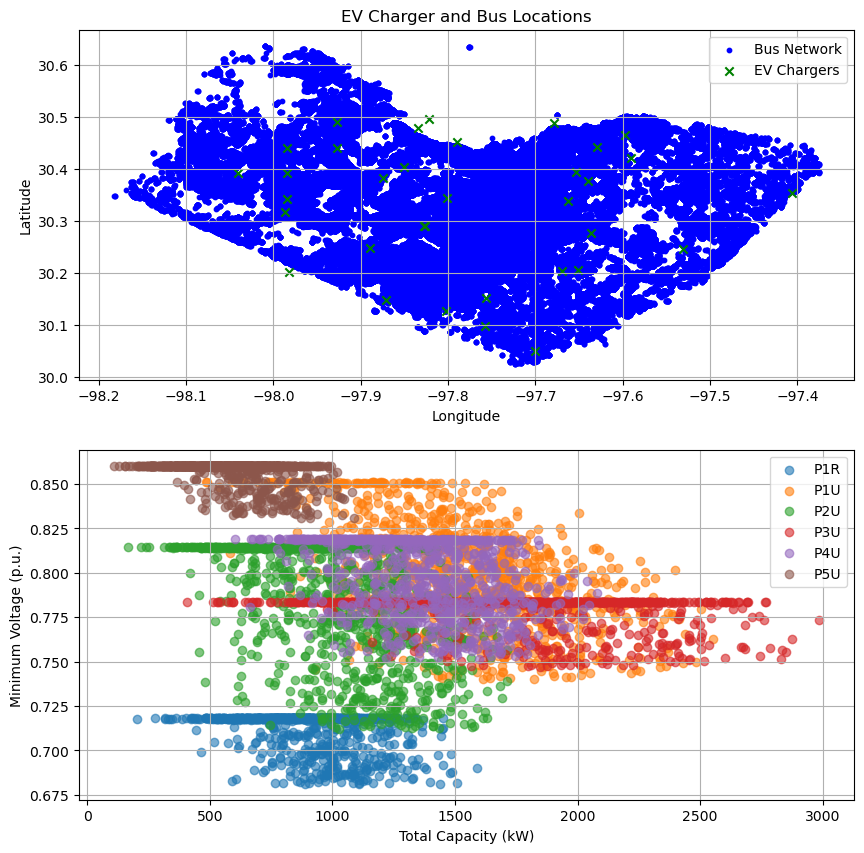

Running Case 1
P1R: No Vmin value is below the threshold.
P1U: 799.8556555799414kW
P2U: No Vmin value is below the threshold.
P3U: 1096.329480881955kW
P4U: 446.0753259678528kW
P5U: No Vmin value is below the threshold.


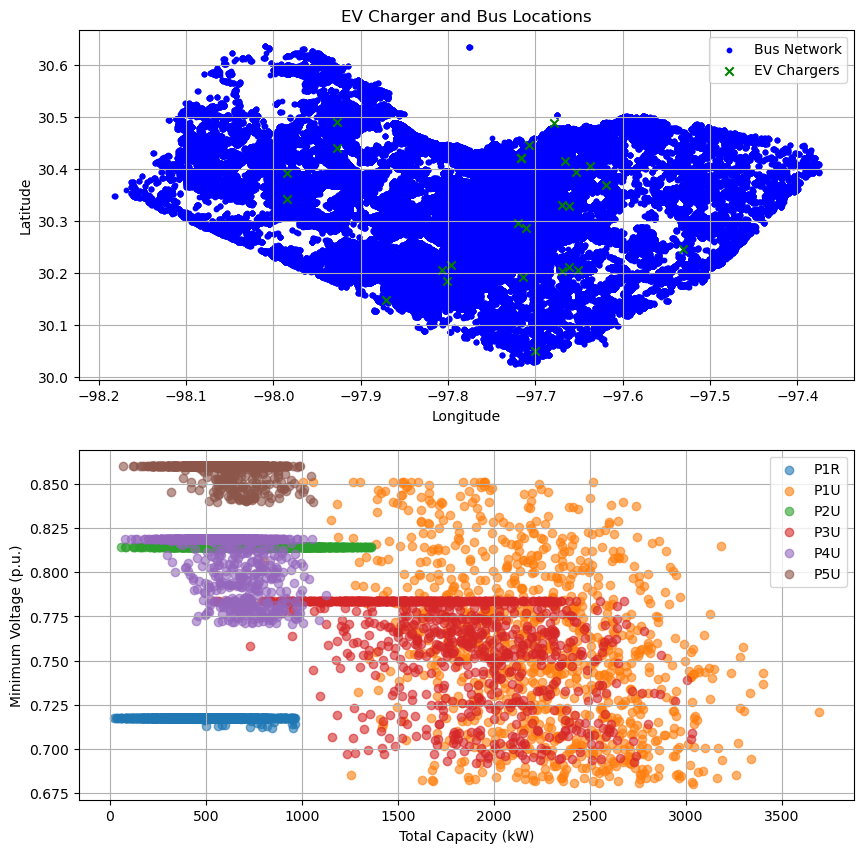

Running Case 2
P1R: 812.6365786794408kW
P1U: 314.397230500309kW
P2U: No Vmin value is below the threshold.
P3U: 398.1709107270888kW
P4U: 615.5155339069457kW
P5U: No Vmin value is below the threshold.


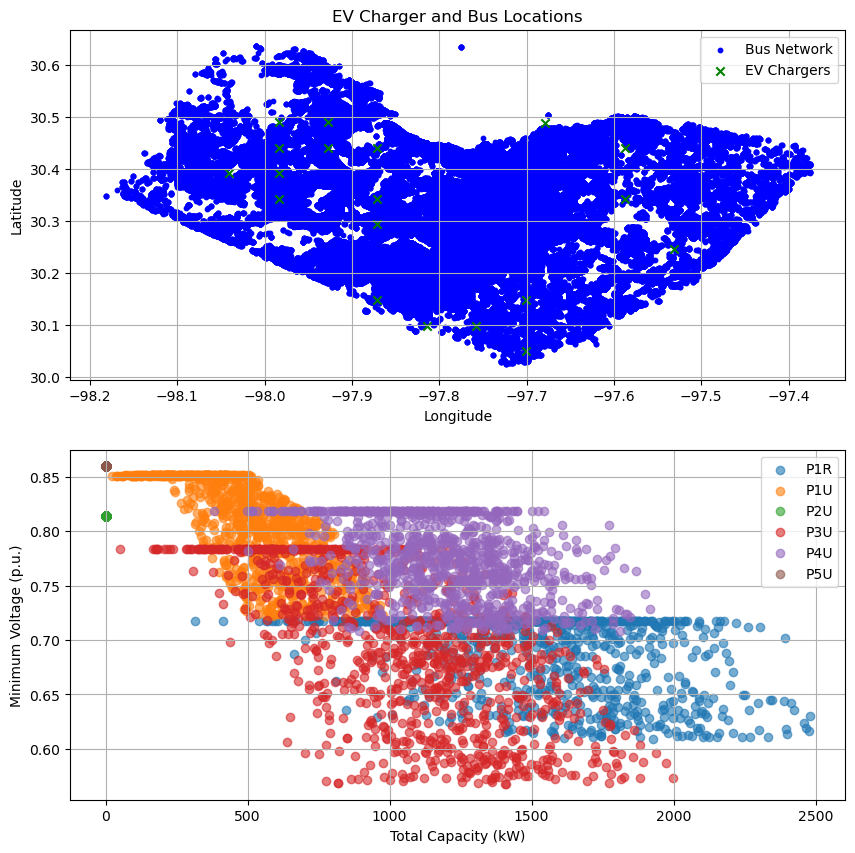

Running Case 3
P1R: 807.4476209557988kW
P1U: No Vmin value is below the threshold.
P2U: 465.6077963119366kW
P3U: No Vmin value is below the threshold.
P4U: 794.343425285614kW
P5U: No Vmin value is below the threshold.


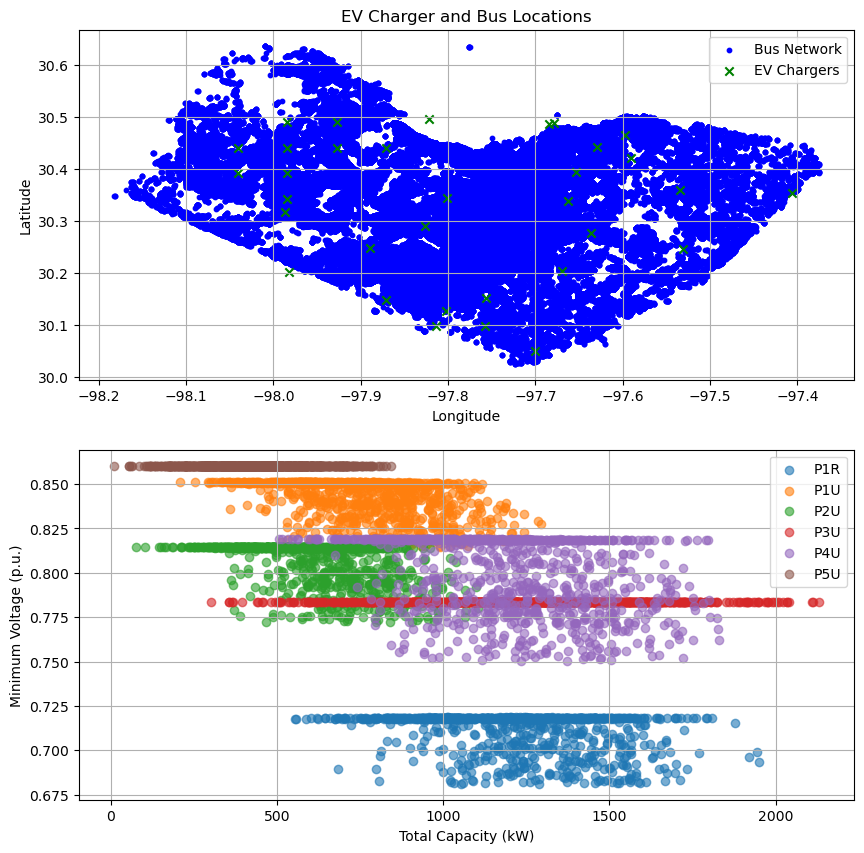

Running Case 4
P1R: 807.7711588297487kW
P1U: 196.29542776214484kW
P2U: No Vmin value is below the threshold.
P3U: 648.026945177678kW
P4U: 532.7058841625715kW
P5U: No Vmin value is below the threshold.


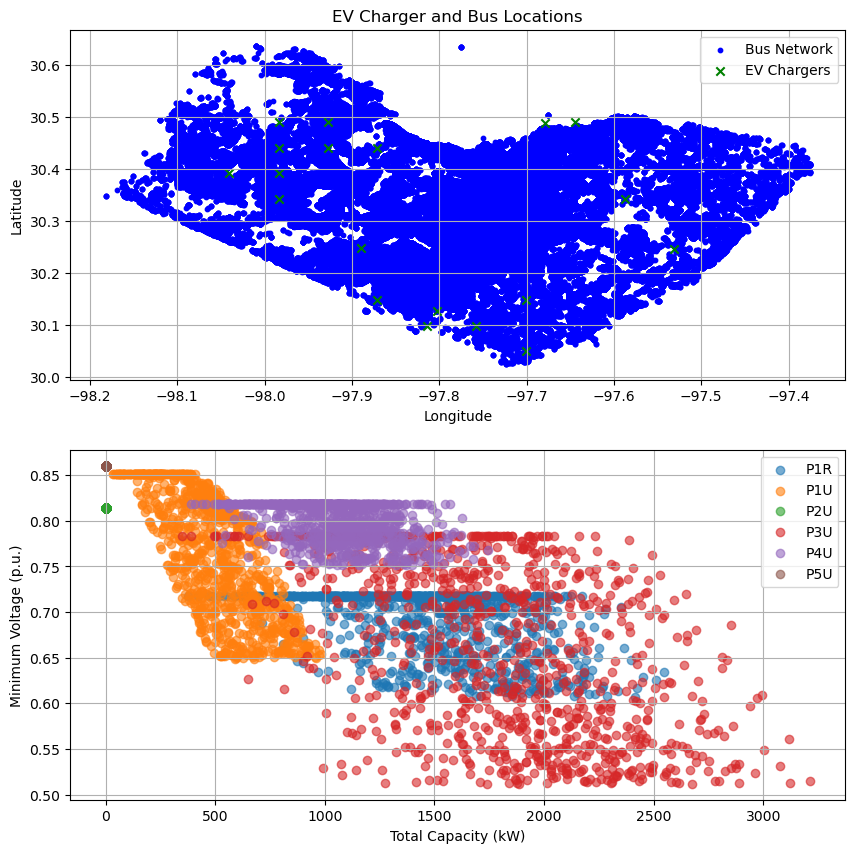

Running Case 5
P1R: 828.0390759196387kW
P1U: 203.05782149286975kW
P2U: No Vmin value is below the threshold.
P3U: 402.9876814220388kW
P4U: 573.4491939521976kW
P5U: No Vmin value is below the threshold.


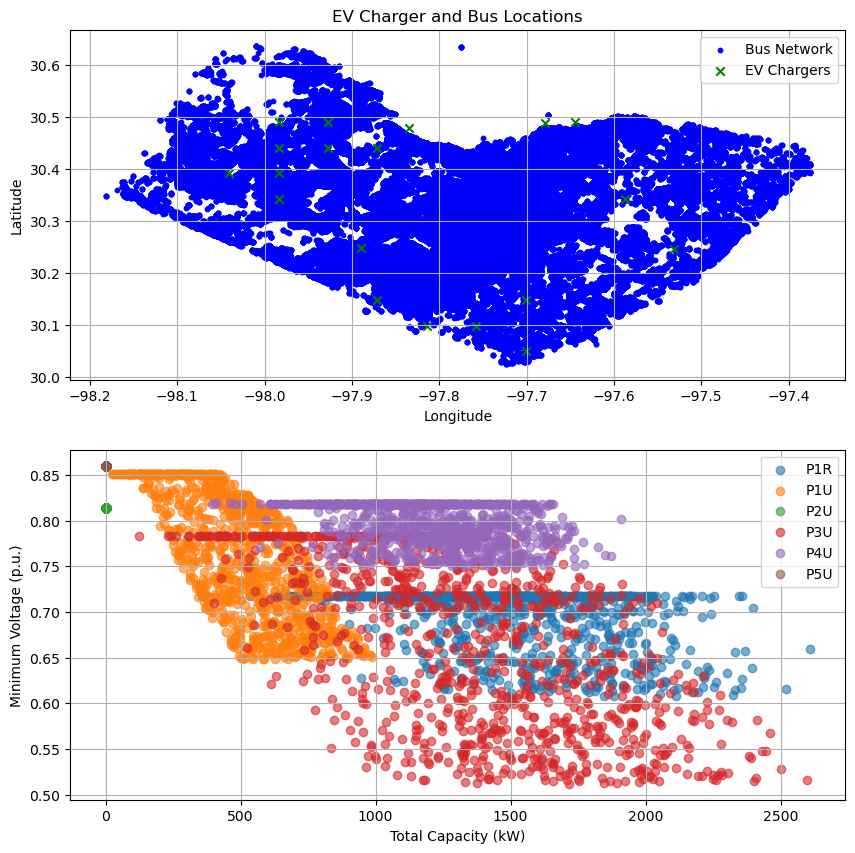

Running Case 6
P1R: 699.8139843445031kW
P1U: 196.58946972939688kW
P2U: No Vmin value is below the threshold.
P3U: 469.67004864873377kW
P4U: 756.6902056926933kW
P5U: No Vmin value is below the threshold.


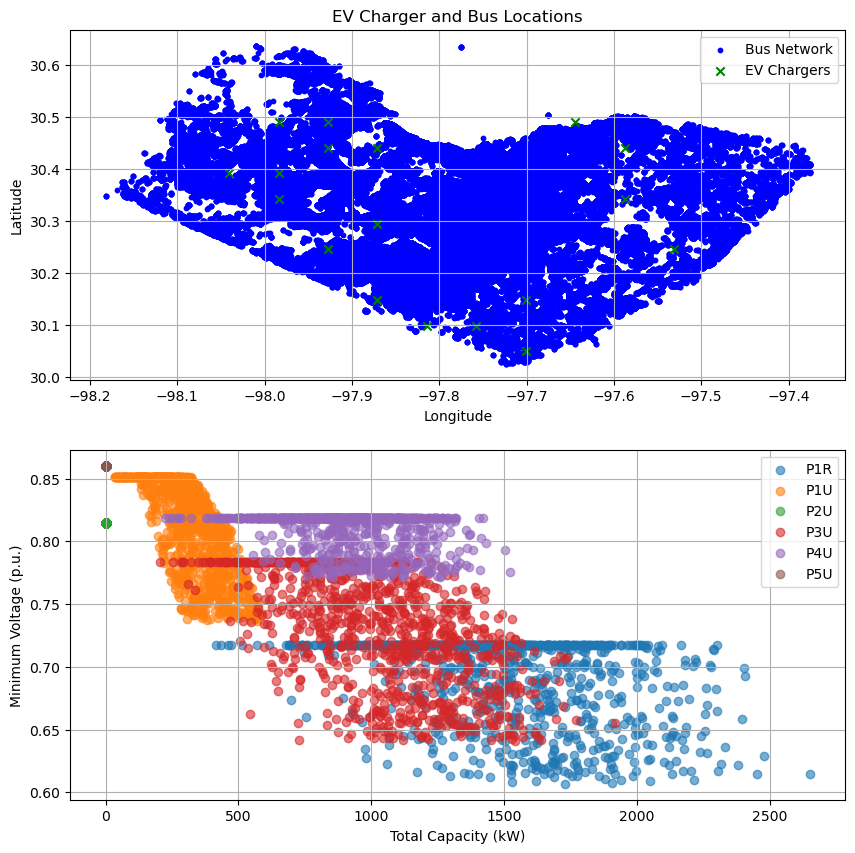

,Case,P1R,P1U,P2U,P3U,P4U,P5U
0,0,590.742683,826.891747,454.061492,2984.133229,900.521117,1087.800201
1,1,963.402843,799.855656,1361.859544,1096.329481,446.075326,1055.789904
2,2,812.636579,314.397231,NaN,398.170911,615.515534,NaN
3,3,807.447621,1295.026561,465.607796,2130.024678,794.343425,844.364049
4,4,807.771159,196.295428,NaN,648.026945,532.705884,NaN
5,5,828.039076,203.057821,NaN,402.987681,573.449194,NaN
6,6,699.813984,196.589470,NaN,469.670049,756.690206,NaN


In [15]:
cur_path = get_current_path()
all_results_HC = {}

for caseidx in range(7):
    print(f"Running Case {caseidx}")
    case_results = plot_map_Vmin(caseidx, cur_path, True)

    for feeder, hc_value_list in case_results.items():
        if feeder not in all_results_HC:
            all_results_HC[feeder] = []
        all_results_HC[feeder].append(hc_value_list[0])  # Only one value per case

df_hc = pd.DataFrame(all_results_HC)
# df_hc.columns = [f"Case {i}" for i in range(7)]
df_hc.reset_index(inplace=True)
df_hc.rename(columns={"index": "Case"}, inplace=True)

df_hc

In [5]:
AusGridPath = r"D:\AUS"
masterpath = r"scenarios\base_timeseries\opendss_no_loadshapes\Master.dss"
buscoords_path = r"scenarios\base_timeseries\opendss_no_loadshapes\Buscoords.dss"
def compile_dss_files(AusGridPath, masterpath, buscoords_path):
    subGridPath = os.listdir(AusGridPath)
    MasterPaths = [
        os.path.join(AusGridPath, a, masterpath)
        for a in subGridPath
    ]
    BusPaths = [
        os.path.join(AusGridPath, a, buscoords_path)
        for a in subGridPath
    ]
    return MasterPaths, BusPaths, subGridPath
# derive EVplanData to nearest bus then to power region
def Charger_to_power_region(caseidx):
    cur_path = get_current_path()
    EVplanData,_ = derive_nearest_bus(caseidx)
    MasterPaths, BusPaths, subGridPath = compile_dss_files(AusGridPath, masterpath, buscoords_path)
    case_indices = list(range(len(MasterPaths)))
    # case_indices = [4]
    for pathidx in case_indices:
        master_file_path = MasterPaths[pathidx]
        region_name = subGridPath[pathidx]
        
        # for pathidx, master_file_path in enumerate([MasterPaths[1]]):
        # Compile the DSS file
        dss.Command(f"compile {master_file_path}")
        # defining the bus names based on opendss circuit
        bus_names = dss.Circuit.AllBusNames()
        EVplanData.loc[EVplanData['NearestBus'].isin(bus_names),'Pwr_Region'] = subGridPath[pathidx]

    return EVplanData

# all_cases_EVplanData = []
# for caseidx in range(7):
#     print(f"Running Case {caseidx}")
    
#     EVplanData = Charger_to_power_region(caseidx)
#     all_cases_EVplanData.append(EVplanData)
        

In [6]:
# EVplanData = Charger_to_power_region(0)

In [7]:
if not os.path.exists(f"Cases{EVplanningFolder}\\ProcessedEVplanData"):
    os.makedirs(f"Cases{EVplanningFolder}\\ProcessedEVplanData")
# set the case from 1 to 6 instead of 0 to 6
all_cases_EVplanData = []
for caseidx in range(7):
    print(f"Running Case {caseidx}")    
    EVplanData = Charger_to_power_region(caseidx)
    cur_path = get_current_path()
    EVplanData.to_csv(f"Cases{EVplanningFolder}\\ProcessedEVplanData\\EVplanData_case{caseidx}.csv", index=False)
    all_cases_EVplanData.append(EVplanData)
all_cases_EVplanData = pd.concat(all_cases_EVplanData, ignore_index=True)

    

Running Case 0
Running Case 1
Running Case 2
Running Case 3
Running Case 4
Running Case 5
Running Case 6


In [16]:
cur_path = get_current_path()
all_cases_EVplanData = []
for caseidx in range(7):
    region_summary = {}
    EVplanData = pd.read_csv(f"Cases{EVplanningFolder}\\ProcessedEVplanData\\EVplanData_case{caseidx}.csv")
    region_summary = EVplanData.groupby('Pwr_Region')['Extra ports added'].sum()
    summary_row = region_summary.to_frame().T
    summary_row.index = [f"Case {caseidx}"]
    all_cases_EVplanData.append(summary_row)
all_cases_EVplanData = pd.concat(all_cases_EVplanData).fillna(0).astype(int).reset_index().rename(columns={'index': 'Case'})
# all_cases_EVplanData.to_csv("CasesResults\\ProcessedEVplanData\\all_cases_EVplanData.csv", index=False)

all_cases_EVplanData['Total Ports'] = all_cases_EVplanData[['P1R', 'P1U', 'P2U', 'P3U', 'P4U', 'P5U']].sum(axis=1)
all_cases_EVplanData

Pwr_Region,Case,P1R,P1U,P2U,P3U,P4U,P5U,Total Ports
0,Case 0,25,12,4,11,25,4,81
1,Case 1,8,28,4,17,16,8,81
2,Case 2,30,5,0,11,35,0,81
3,Case 3,26,8,4,9,30,4,81
4,Case 4,29,5,0,13,34,0,81
5,Case 5,29,5,0,11,36,0,81
6,Case 6,28,9,0,13,31,0,81


In [17]:
region_data = all_cases_EVplanData.iloc[:, 1:-1]
ports_kw_7_2 = region_data * 7.2
ports_kw_14 = region_data * 14

ports_kw_7_2.insert(0, 'Case', all_cases_EVplanData['Case'])
ports_kw_14.insert(0, 'Case', all_cases_EVplanData['Case'])

ports_kw_7_2
ports_kw_14

Pwr_Region,Case,P1R,P1U,P2U,P3U,P4U,P5U
0,Case 0,350,168,56,154,350,56
1,Case 1,112,392,56,238,224,112
2,Case 2,420,70,0,154,490,0
3,Case 3,364,112,56,126,420,56
4,Case 4,406,70,0,182,476,0
5,Case 5,406,70,0,154,504,0
6,Case 6,392,126,0,182,434,0


In [18]:
df_hc
df_hc.columns[1:]
df_hc.shape[0]



7

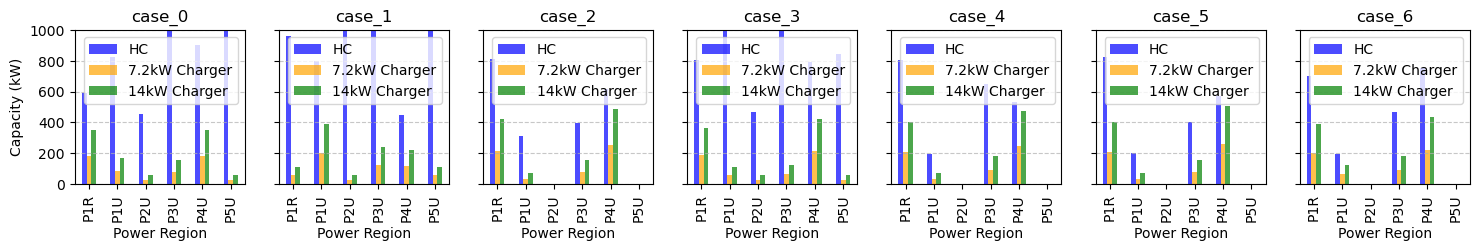

In [19]:
num_cases = df_hc.shape[0]
num_regions = len(df_hc.columns[1:])

fig, axs = plt.subplots(ncols=num_cases, nrows=1, figsize=(18, 2), sharex=True, sharey=True)
for i in range(num_cases):
    case_label = df_hc['Case'].iloc[i]
    hc = df_hc.iloc[i, 1:].fillna(0)
    load_7_2 = ports_kw_7_2.iloc[i, :].fillna(0)
    load_14 = ports_kw_14.iloc[i, :].fillna(0)
    df_plot = pd.DataFrame({'HC': hc, '7.2kW Charger': load_7_2, '14kW Charger': load_14},index=df_hc.columns[1:])
    ax = axs[i]
    df_plot.plot(kind='bar', ax=ax, color=['blue', 'orange', 'green'], alpha=0.7)
    ax.set_title(f"case_{i}")
    # set the y-axis limit to 0 to 1000
    ax.set_ylim(0, 1000)
    ax.set_ylabel('Capacity (kW)')
    ax.set_xlabel('Power Region')
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    ax.legend(loc='upper right')

In [12]:
df_hc

,Case,P1R,P1U,P2U,P3U,P4U,P5U
0,0,442.806267,584.013665,419.294893,977.275140,663.762697,367.206553
1,1,501.153743,799.855656,1361.859544,729.459369,295.952042,318.042559
2,2,662.620491,240.688105,NaN,306.796126,500.392943,NaN
3,3,683.791247,359.830108,361.993959,2130.024678,674.673513,844.364049
4,4,714.865142,144.499634,NaN,648.026945,532.705884,NaN
5,5,797.401395,139.516338,NaN,402.987681,573.449194,NaN
6,6,699.813984,132.285128,NaN,310.031140,554.110050,NaN
